# Random Forest класификация: нисък / среден / висок риск

Цел: да класифицираме EURO-D скалата в три категории (0–3 нисък, 4–7 среден, 8+ висок) и да визуализираме резултатите и важностите (вкл. SHAP).

In [44]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8")
sns.set_palette("Dark2")

In [45]:
# Зареждане на подготвените таблици
PROJECT_ROOT = Path.cwd().resolve().parent  # notebook/ -> project root
train_path = PROJECT_ROOT / "Dataset" / "processed" / "train_prepared.parquet"
test_path = PROJECT_ROOT / "Dataset" / "processed" / "test_prepared.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)


FEATURE_COLUMNS = [c for c in train_df.columns if c != "eurod"]
TARGET_COLUMN = "eurod"

In [46]:
# Дефиниция на трите риска: 0–3 нисък, 4–7 среден, 8+ висок
def bucketize(series: pd.Series) -> pd.Series:
    bins = [ -np.inf, 3, 7, np.inf ]
    labels = ["low", "medium", "high"]
    return pd.cut(series, bins=bins, labels=labels, right=True, include_lowest=True)

train_df["risk"] = bucketize(train_df[TARGET_COLUMN])
test_df["risk"] = bucketize(test_df[TARGET_COLUMN])

class_names = ["low", "medium", "high"]
class_to_id = {c: i for i, c in enumerate(class_names)}

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["risk"].map(class_to_id)
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["risk"].map(class_to_id)

train_df[["eurod", "risk"]].head()

,eurod,risk
0,1.0,low
1,4.0,medium
2,4.0,medium
3,5.0,medium
4,4.0,medium


In [47]:
# Леко търсене на хиперпараметри върху отделен валидационен дял от train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

param_grid = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 2},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 600, "max_depth": 14, "min_samples_leaf": 2},
]

val_results = []
best = None
for params in param_grid:
    clf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", **params)
    clf.fit(X_tr, y_tr)
    val_pred = clf.predict(X_val)
    f1 = f1_score(y_val, val_pred, average="macro")
    acc = accuracy_score(y_val, val_pred)
    val_results.append({"params": params, "val_f1_macro": f1, "val_acc": acc})
    if best is None or f1 > best[0]:
        best = (f1, params)

pd.DataFrame(val_results).sort_values("val_f1_macro", ascending=False)

,params,val_f1_macro,val_acc
3,"{'n_estimators': 600, 'max_depth': 14, 'min_sa...",0.558645,0.712420
1,"{'n_estimators': 400, 'max_depth': None, 'min_...",0.553725,0.755288
2,"{'n_estimators': 400, 'max_depth': 10, 'min_sa...",0.542221,0.679808
0,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.475387,0.757292


In [48]:
# Обучение на най-добрия модел върху целия train и оценка на test
best_params = best[1]
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", **best_params)
rf_clf.fit(X_train, y_train)

train_pred = rf_clf.predict(X_train)
test_pred = rf_clf.predict(X_test)

def report(y_true, y_pred, split_name):
    print(f"=== {split_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 macro:", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

report(y_train, train_pred, "TRAIN")
report(y_test, test_pred, "TEST")

=== TRAIN ===
Accuracy: 0.8025898265970063
F1 macro: 0.7768778311731767
              precision    recall  f1-score   support

         low      0.911     0.822     0.864     45673
      medium      0.567     0.721     0.635     14407
        high      0.750     0.934     0.832      2318

    accuracy                          0.803     62398
   macro avg      0.743     0.825     0.777     62398
weighted avg      0.825     0.803     0.810     62398

=== TEST ===
Accuracy: 0.7064102564102565
F1 macro: 0.5638494279794037
              precision    recall  f1-score   support

         low      0.862     0.772     0.814     11419
      medium      0.412     0.547     0.470      3601
        high      0.400     0.416     0.407       580

    accuracy                          0.706     15600
   macro avg      0.558     0.578     0.564     15600
weighted avg      0.741     0.706     0.720     15600



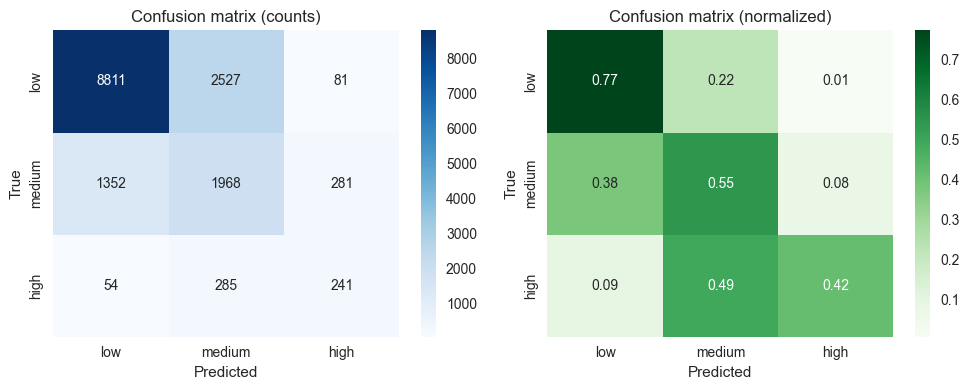

In [49]:
# Confusion matrix (test)
cm = confusion_matrix(y_test, test_pred, labels=list(range(len(class_names))))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title("Confusion matrix (counts)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title("Confusion matrix (normalized)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

plt.tight_layout()
plt.show()

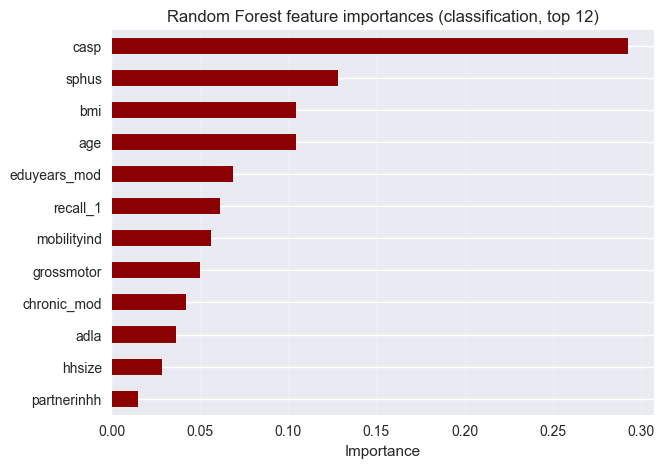

casp            0.292851
sphus           0.128161
bmi             0.104634
age             0.104549
eduyears_mod    0.068850
recall_1        0.061572
mobilityind     0.056074
grossmotor      0.050283
chronic_mod     0.041944
adla            0.036437
hhsize          0.028415
partnerinhh     0.015053
dtype: float64

In [50]:
# Важности на признаците (топ 12)
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
top_importances = importances.head(12)

plt.figure(figsize=(7, 5))
top_importances.sort_values().plot(kind="barh", color="darkred")
plt.xlabel("Importance")
plt.title("Random Forest feature importances (classification, top 12)")
plt.grid(True, axis="x", alpha=0.2)
plt.show()

top_importances

## Бележки
- Данните са предварително почистени/скалирани (MinMax + импутиране) от подготовката на `train_prepared`/`test_prepared`.
- Класовете са балансирани чрез `class_weight='balanced'`.
- Хиперпараметрите са подбрани с малка решетка; може да се разшири за още печалба.
- SHAP визуализациите показват как всеки признак бута към/против конкретен клас; за по-бърза работа ограничаваме до 2k примера.